In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')

BASE_DIR = Path.cwd().parent
DB_PATH  = BASE_DIR / 'database' / 'olist.db'

engine = create_engine(f'sqlite:///{DB_PATH}')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Business Question A : Delivery speed
* Do customers who wait longer give lower review scores? (A negative correlation?or relationship)
* Economics angle: customer utility decreases as waiting cost increases ?(nicroeconomics utility)

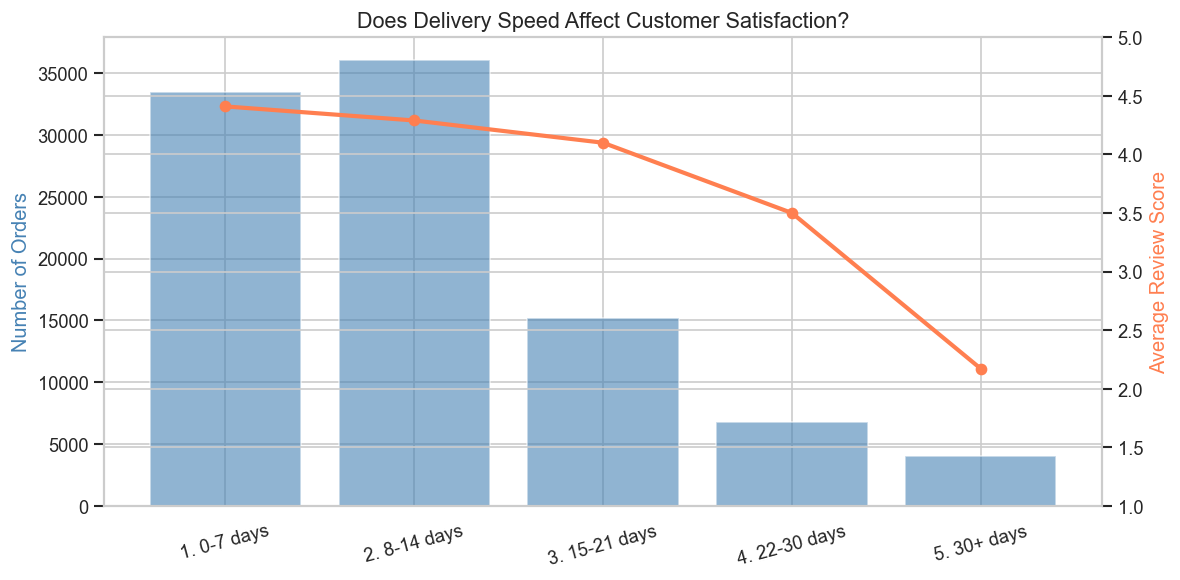

INSIGHT:
delivery_bucket  order_count  avg_review_score
    1. 0-7 days        33488              4.41
   2. 8-14 days        36099              4.29
  3. 15-21 days        15218              4.10
  4. 22-30 days         6807              3.50
    5. 30+ days         3995              2.17


In [8]:
delivery_satisfaction = pd.read_sql("""
    SELECT
        CASE
            WHEN actual_delivery_days <= 7  THEN '1. 0-7 days'
            WHEN actual_delivery_days <= 14 THEN '2. 8-14 days'
            WHEN actual_delivery_days <= 21 THEN '3. 15-21 days'
            WHEN actual_delivery_days <= 30 THEN '4. 22-30 days'
            ELSE                                 '5. 30+ days'
        END                              AS delivery_bucket,
        COUNT(oc.order_id)               AS order_count,
        ROUND(AVG(r.review_score), 2)    AS avg_review_score

    FROM orders_clean oc
    JOIN order_reviews r ON oc.order_id = r.order_id

    WHERE oc.actual_delivery_days IS NOT NULL
      AND oc.actual_delivery_days >= 0

    GROUP BY delivery_bucket
    ORDER BY delivery_bucket
""", engine)

fig, ax1 = plt.subplots(figsize=(10, 5))

# Bar chart = order volume per delivery bucket
ax1.bar(delivery_satisfaction['delivery_bucket'],
        delivery_satisfaction['order_count'],
        color='steelblue', alpha=0.6, label='Order Count')
ax1.set_ylabel('Number of Orders', color='steelblue')
ax1.tick_params(axis='x', rotation=15)# Rotate x-axis Labels for better readabili

# Line chart = review score trend across buckets
ax2 = ax1.twinx()
ax2.plot(delivery_satisfaction['delivery_bucket'],
         delivery_satisfaction['avg_review_score'],
         color='coral', marker='o', linewidth=2.5)
ax2.set_ylabel('Average Review Score', color='coral')
ax2.set_ylim(1, 5)

plt.title('Does Delivery Speed Affect Customer Satisfaction?', fontsize=13)
fig.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'processed' / 'delivery_vs_satisfaction.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Insight ──────────────────────────────────────────────────────
print("INSIGHT:")
print(delivery_satisfaction[['delivery_bucket',
                              'order_count',
                              'avg_review_score']].to_string(index=False))

# Business Question B: Worst delivery performance
* Which customer states suffer the longest deliveries and lowest satisfaction?
* Economics angle: geographic market segmentation — logistics cost vs revenue tradeoff

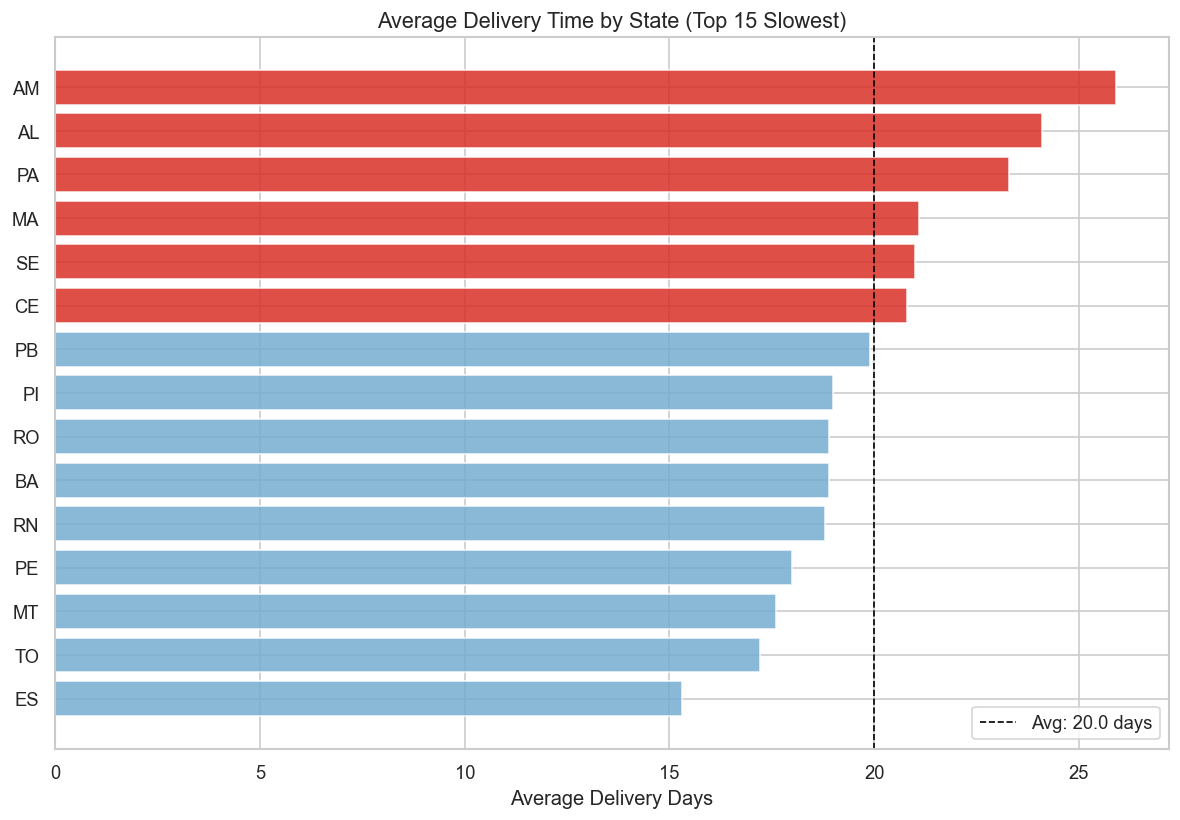

INSIGHT:
state  avg_delivery_days  avg_review_score  avg_days_early_or_late
   AM               25.9              4.22                    18.6
   AL               24.1              3.86                     7.7
   PA               23.3              3.92                    13.1
   MA               21.1              3.83                     8.6
   SE               21.0              3.90                     9.0
   CE               20.8              3.95                     9.8
   PB               19.9              4.07                    12.3
   PI               19.0              3.99                    10.3
   RO               18.9              4.17                    19.1
   BA               18.9              3.93                     9.8
   RN               18.8              4.15                    12.7
   PE               18.0              4.08                    12.3
   MT               17.6              4.15                    13.4
   TO               17.2              4.16           

In [9]:
# LIMIT 15(15 rows) to focus on states with the Top 15 slowest states
state_delivery = pd.read_sql("""
    SELECT
        c.customer_state                       AS state,
        COUNT(DISTINCT oc.order_id)            AS total_orders,
        ROUND(AVG(oc.actual_delivery_days), 1) AS avg_delivery_days,
        ROUND(AVG(r.review_score), 2)          AS avg_review_score,
        ROUND(AVG(oc.early_or_late_days), 1)   AS avg_days_early_or_late

    FROM orders_clean oc
    JOIN customers c          ON oc.customer_id = c.customer_id
    LEFT JOIN order_reviews r ON oc.order_id    = r.order_id

    WHERE oc.actual_delivery_days IS NOT NULL

    GROUP BY state
    HAVING COUNT(DISTINCT oc.order_id) > 100

    ORDER BY avg_delivery_days DESC
    LIMIT 15
""", engine)

# HAVING explained:
# WHERE filters rows BEFORE grouping
# HAVING filters AFTER grouping — used to filter on aggregated values
# here we only include states with more than 100 orders (enough data to be meaningful)

fig, ax = plt.subplots(figsize=(10, 7))

# Colour bars red if avg delivery > 20 days, blue otherwise
colors = ['#d73027' if d > 20 else '#74add1'
          for d in state_delivery['avg_delivery_days']]

ax.barh(state_delivery['state'][::-1],
        state_delivery['avg_delivery_days'][::-1],
        color=colors[::-1], alpha=0.85)

# National average line for reference
national_avg = state_delivery['avg_delivery_days'].mean()
ax.axvline(national_avg, color='black', linestyle='--', linewidth=1,
           label=f'Avg: {national_avg:.1f} days')

ax.set_xlabel('Average Delivery Days')
ax.set_title('Average Delivery Time by State (Top 15 Slowest)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'processed' / 'delivery_by_state.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("INSIGHT:")
print(state_delivery[['state', 'avg_delivery_days',
                       'avg_review_score',
                       'avg_days_early_or_late']].to_string(index=False))
print("Although AM state has the longest delivery time and its highest average review score") 
print("\nThis is because it has a early delivery time of 18.6days in column avg_days_early_or_late which is posotive=early,negative=late")

# Business Question C: Payment behaviour analysis
* How do customers pay and does payment method affect order value?
* Economics angle: price sensitivity and credit access across income segments

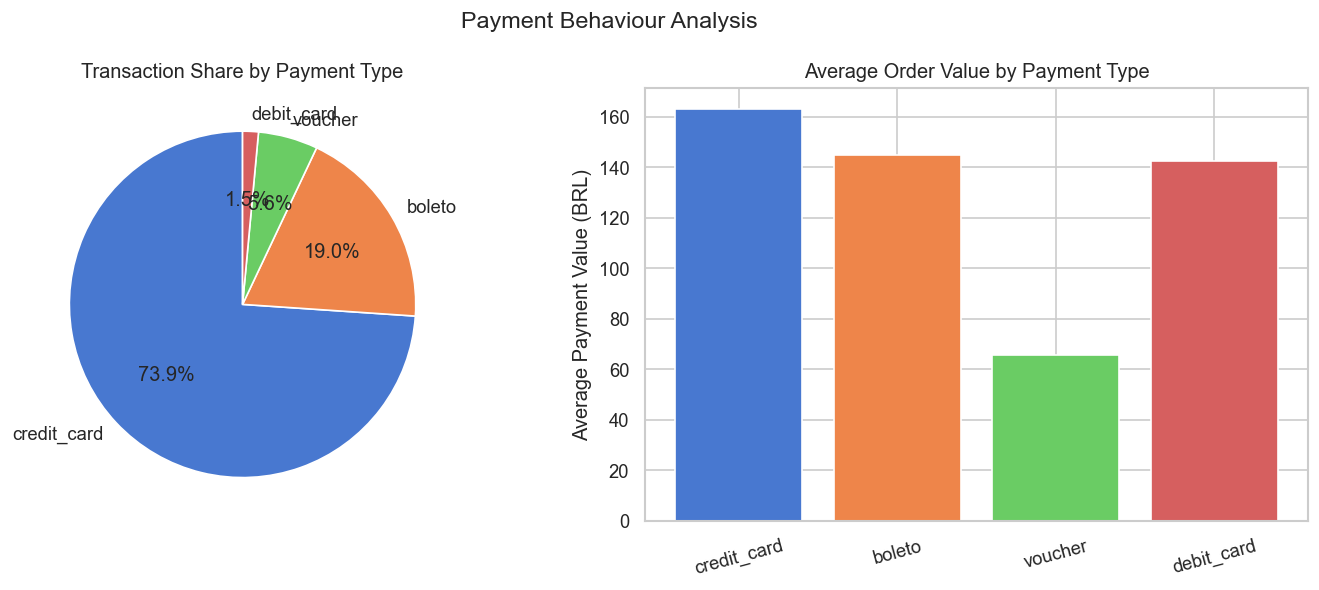

INSIGHT:
payment_type  transaction_count  total_value  avg_payment  avg_installments
 credit_card              76795  12542084.19       163.32               3.5
      boleto              19784   2869361.27       145.03               1.0
     voucher               5775    379436.87        65.70               1.0
  debit_card               1529    217989.79       142.57               1.0


In [10]:
payment_behaviour = pd.read_sql("""
    SELECT
        payment_type,
        COUNT(*)                            AS transaction_count,
        ROUND(SUM(payment_value), 2)        AS total_value,
        ROUND(AVG(payment_value), 2)        AS avg_payment,
        ROUND(AVG(payment_installments), 1) AS avg_installments
    FROM order_payments
    WHERE payment_type != 'not_defined'
    GROUP BY payment_type
    ORDER BY transaction_count DESC
""", engine)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (Pie) Left chart: Transaction share by payment behaviour
axes[0].pie(payment_behaviour['transaction_count'],
            labels=payment_behaviour['payment_type'],
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('muted', len(payment_behaviour)))
axes[0].set_title('Transaction Share by Payment Type')

# (Bar) Right chart: Average order value by payment behaviour
axes[1].bar(payment_behaviour['payment_type'],
            payment_behaviour['avg_payment'],
            color=sns.color_palette('muted', len(payment_behaviour)))
axes[1].set_ylabel('Average Payment Value (BRL)')
axes[1].set_title('Average Order Value by Payment Type')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Payment Behaviour Analysis', fontsize=14)
plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'processed' / 'payment_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("INSIGHT:")
print(payment_behaviour.to_string(index=False))

## Key Business Insights

### A — Delivery speed vs customer satisfaction
* Review scores drop sharply once delivery exceeds 14 days
* Orders delivered within 7 days score significantly higher than 30+ day orders
* **Recommendation:** Prioritise logistics investment for orders going to distant states

### B — State delivery performance
* Northern states (AM, RR, AP) show the longest average delivery times
* These same states show the lowest average review scores
* Positive early_or_late_days = delivered before estimate — most states manage this
* **Recommendation:** Regional fulfilment centres in northern Brazil would reduce delivery
  times and improve customer satisfaction in underserved markets

### C — Payment behaviour
* Credit card dominates both volume and average order value
* High instalment usage suggests price-sensitive buyers
* Boleto users place smaller orders — typical of lower income or unbanked segments
* **Recommendation:** Instalment promotions could increase average order value
  among credit card users who are already comfortable with split payments